In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# Download ETF DATA

tickers = ["SPY","QQQ","TLT","GLD","SHY"]
prices = yf.download(
    tickers,
    start = "2015-01-01",
    auto_adjust = True,
    progress = False
)["Open"]

prices.head()

    
    

Ticker,GLD,QQQ,SHY,SPY,TLT
Date,,,,,
2015-01-02,112.489998,95.419130,68.650068,170.911729,92.249135
2015-01-05,114.779999,94.251224,68.633820,169.081540,93.505528
2015-01-06,116.220001,93.414391,68.706898,167.359043,95.470423
2015-01-07,116.470001,92.632758,68.731303,166.804123,95.470411
2015-01-08,116.449997,94.002924,68.747597,168.949020,95.222065


In [4]:
# checking rows and column
print(prices.shape)

(2873, 5)


In [5]:
# checking missing values
print(prices.isna().sum())

Ticker
GLD    0
QQQ    0
SHY    0
SPY    0
TLT    0
dtype: int64


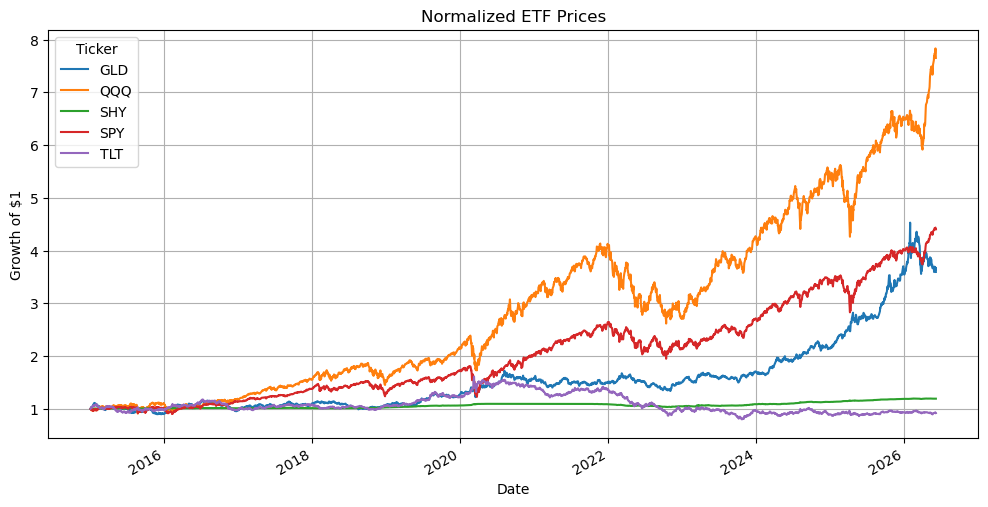

In [6]:
# ETF have different starting vaues, so normalization makes them comparable
normalized_prices = prices / prices.iloc[0]

normalized_prices.plot(figsize=(12,6))

plt.title("Normalized ETF Prices")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [7]:
#calculate returns
returns = prices.pct_change().dropna()

returns.head()

Ticker,GLD,QQQ,SHY,SPY,TLT
Date,,,,,
2015-01-05,0.020357,-0.012240,-0.000237,-0.010708,1.361955e-02
2015-01-06,0.012546,-0.008879,0.001065,-0.010187,2.101368e-02
2015-01-07,0.002151,-0.008367,0.000355,-0.003316,-1.244771e-07
2015-01-08,-0.000172,0.014791,0.000237,0.012859,-2.601281e-03
2015-01-09,0.000515,0.013696,0.000709,0.011715,-8.898395e-03


In [8]:
# Market features

# Use SPY as the market proxy
spy = prices["SPY"]
spy_returns = spy.pct_change()

# Create a dataframe to store regime features
features = pd.DataFrame(index=prices.index)

# 21-day and 63-day momentum
features["ret_21d"] = spy.pct_change(21)
features["ret_63d"] = spy.pct_change(63)

# 21-day and 63-day annualized volatility
features["vol_21d"] = spy_returns.rolling(21).std() * np.sqrt(252)
features["vol_63d"] = spy_returns.rolling(63).std() * np.sqrt(252)

# Trend indicator using 50-day and 200-day moving averages
ma50 = spy.rolling(50).mean()
ma200 = spy.rolling(200).mean()

features["trend_50_200"] = ma50 / ma200 - 1

# Drawdown from previous peak
rolling_peak = spy.cummax()
features["drawdown"] = spy / rolling_peak - 1

# Remove rows with missing values
features = features.dropna()

features.head()

,ret_21d,ret_63d,vol_21d,vol_63d,trend_50_200,drawdown
Date,,,,,,
2015-10-16,0.019321,-0.041671,0.204063,0.247873,-0.030886,-0.041671
2015-10-19,0.034694,-0.041789,0.194317,0.247875,-0.031313,-0.043230
2015-10-20,0.032630,-0.033307,0.194177,0.247560,-0.031875,-0.041577
2015-10-21,0.050186,-0.032437,0.186803,0.247615,-0.032399,-0.037986
2015-10-22,0.045696,-0.029789,0.187740,0.247433,-0.032804,-0.040962


In [9]:
# Scale all features so they have similar magnitude
scaler = StandardScaler()

X = scaler.fit_transform(features)

X[:5]

array([[ 0.13938089, -1.13107725,  0.64677102,  1.20614149, -1.53556474,
         0.02475321],
       [ 0.47805488, -1.13278511,  0.53659313,  1.20616781, -1.54494455,
        -0.00268697],
       [ 0.43260005, -1.0102139 ,  0.5350073 ,  1.20211266, -1.55728324,
         0.02641135],
       [ 0.81935517, -0.99764791,  0.45165596,  1.20282027, -1.56878552,
         0.08960355],
       [ 0.7204401 , -0.9593832 ,  0.46224326,  1.20047288, -1.57767786,
         0.03722499]])

In [10]:
# Cluster market conditions into 3 regimes
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

# Assign each date to one market cluster
features["cluster"] = kmeans.fit_predict(X)

features.head()

,ret_21d,ret_63d,vol_21d,vol_63d,trend_50_200,drawdown,cluster
Date,,,,,,,
2015-10-16,0.019321,-0.041671,0.204063,0.247873,-0.030886,-0.041671,2
2015-10-19,0.034694,-0.041789,0.194317,0.247875,-0.031313,-0.043230,2
2015-10-20,0.032630,-0.033307,0.194177,0.247560,-0.031875,-0.041577,2
2015-10-21,0.050186,-0.032437,0.186803,0.247615,-0.032399,-0.037986,2
2015-10-22,0.045696,-0.029789,0.187740,0.247433,-0.032804,-0.040962,2


In [11]:
# Calculate average feature values for each cluster
regime_summary = features.groupby("cluster")[[
    "ret_21d",
    "ret_63d",
    "vol_21d",
    "vol_63d",
    "trend_50_200",
    "drawdown"
]].mean()

regime_summary

,ret_21d,ret_63d,vol_21d,vol_63d,trend_50_200,drawdown
cluster,,,,,,
0,0.018135,0.059501,0.113662,0.119959,0.059309,-0.017313
1,-0.060099,-0.068592,0.271365,0.225809,-0.003771,-0.141061
2,0.055902,0.014070,0.206598,0.272047,-0.029638,-0.088179


In [12]:
# Manually map cluster numbers to regime names
features["regime"] = features["cluster"].map({
    0: "Bullish",
    1: "Defensive",
    2: "High Volatility"
})

features[["cluster", "regime"]].head()

,cluster,regime
Date,,
2015-10-16,2,High Volatility
2015-10-19,2,High Volatility
2015-10-20,2,High Volatility
2015-10-21,2,High Volatility
2015-10-22,2,High Volatility


In [13]:
def get_weights(regime):
    # If market is bullish, hold more equity exposure
    if regime == "Bullish":
        return {
            "SPY": 0.35,
            "QQQ": 0.35,
            "TLT": 0.10,
            "GLD": 0.10,
            "SHY": 0.10
        }

    # If market is defensive, reduce stocks and increase bonds/gold
    elif regime == "Defensive":
        return {
            "SPY": 0.20,
            "QQQ": 0.15,
            "TLT": 0.30,
            "GLD": 0.20,
            "SHY": 0.15
        }

    # If market is high volatility, become very defensive
    else:
        return {
            "SPY": 0.10,
            "QQQ": 0.05,
            "TLT": 0.35,
            "GLD": 0.25,
            "SHY": 0.25
        }

In [14]:
# Create empty weights dataframe
weights = pd.DataFrame(
    index=features.index,
    columns=tickers
)

# For every date, assign weights based on that day's regime
for date in features.index:
    regime = features.loc[date, "regime"]
    weights.loc[date] = get_weights(regime)

weights.head()

,SPY,QQQ,TLT,GLD,SHY
Date,,,,,
2015-10-16,0.1,0.05,0.35,0.25,0.25
2015-10-19,0.1,0.05,0.35,0.25,0.25
2015-10-20,0.1,0.05,0.35,0.25,0.25
2015-10-21,0.1,0.05,0.35,0.25,0.25
2015-10-22,0.1,0.05,0.35,0.25,0.25


In [15]:
# Match returns dates with weight dates
aligned_returns = returns.loc[weights.index]

aligned_returns.head()

Ticker,GLD,QQQ,SHY,SPY,TLT
Date,,,,,
2015-10-16,0.000353,0.014861,-1.170480e-04,0.013744,-0.000482
2015-10-19,-0.005298,0.000741,8.227232e-08,-0.001627,-0.003702
2015-10-20,-0.002308,0.005279,-4.711874e-04,0.001728,-0.007998
2015-10-21,-0.000089,0.001658,1.185665e-04,0.003747,0.006597
2015-10-22,-0.007564,-0.002299,3.522118e-04,-0.003094,0.003964


In [17]:
#backtest strategy
# Use yesterday's weights to calculate today's return
# This avoids look-ahead bias
strategy_returns = (
    aligned_returns * weights.shift(1)
).sum(axis=1)

strategy_returns.head()

Date
2015-10-16           0
2015-10-19   -0.002746
2015-10-20   -0.003057
2015-10-21    0.002774
2015-10-22    -0.00084
dtype: object

In [18]:
# Growth of $1 invested in adaptive strategy
strategy_curve = (
    1 + strategy_returns
).cumprod()

# Growth of $1 invested in SPY
benchmark_curve = (
    1 + aligned_returns["SPY"]
).cumprod()

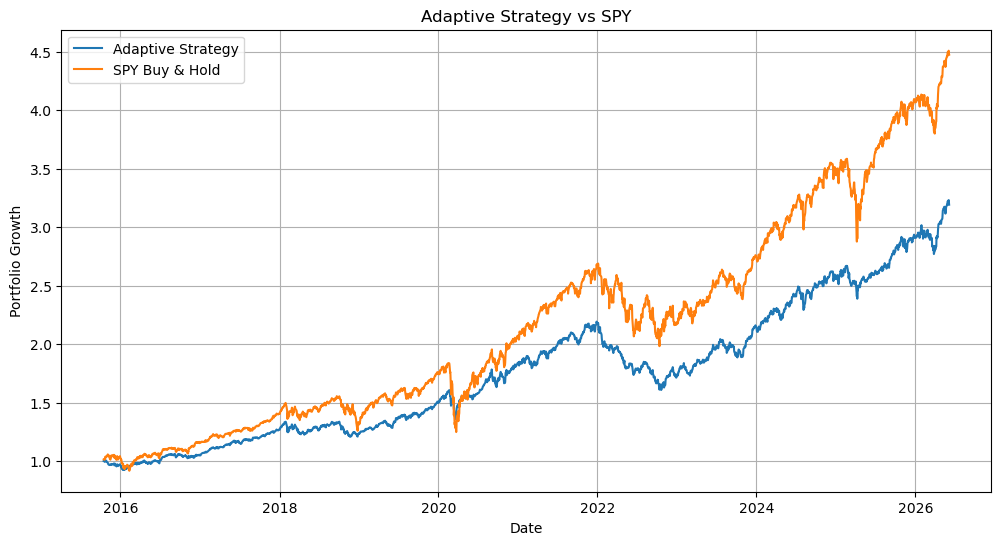

In [19]:
plt.figure(figsize=(12,6))

plt.plot(strategy_curve, label="Adaptive Strategy")
plt.plot(benchmark_curve, label="SPY Buy & Hold")

plt.title("Adaptive Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Portfolio Growth")

plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Sharpe ratio
def sharpe_ratio(returns):
    # Annualized Sharpe ratio
    return np.sqrt(252) * returns.mean() / returns.std()

strategy_sharpe = sharpe_ratio(strategy_returns)
benchmark_sharpe = sharpe_ratio(aligned_returns["SPY"])

print("Strategy Sharpe Ratio:", round(strategy_sharpe, 3))
print("SPY Sharpe Ratio:", round(benchmark_sharpe, 3))

Strategy Sharpe Ratio: 1.089
SPY Sharpe Ratio: 0.914


In [21]:
def max_drawdown(curve):
    # Highest value reached so far
    running_peak = curve.cummax()

    # Percentage fall from peak
    drawdown = curve / running_peak - 1

    # Worst drawdown
    return drawdown.min()

strategy_mdd = max_drawdown(strategy_curve)
benchmark_mdd = max_drawdown(benchmark_curve)

print("Strategy Max Drawdown:", round(strategy_mdd, 3))
print("SPY Max Drawdown:", round(benchmark_mdd, 3))

Strategy Max Drawdown: -0.267
SPY Max Drawdown: -0.32


In [22]:
def cagr(curve):
    # Total return over full period
    total_return = curve.iloc[-1] / curve.iloc[0] - 1

    # Approximate number of trading years
    years = len(curve) / 252

    # Compound annual growth rate
    return (1 + total_return) ** (1 / years) - 1

strategy_cagr = cagr(strategy_curve)
benchmark_cagr = cagr(benchmark_curve)

print("Strategy CAGR:", round(strategy_cagr, 3))
print("SPY CAGR:", round(benchmark_cagr, 3))

Strategy CAGR: 0.116
SPY CAGR: 0.15


In [23]:
# Annualized volatility of strategy and SPY
strategy_volatility = strategy_returns.std() * np.sqrt(252)
benchmark_volatility = aligned_returns["SPY"].std() * np.sqrt(252)

print("Strategy Volatility:", round(strategy_volatility, 3))
print("SPY Volatility:", round(benchmark_volatility, 3))

Strategy Volatility: 0.106
SPY Volatility: 0.171


In [30]:
summary = pd.DataFrame({

    "Metric": [
        "CAGR",
        "Sharpe Ratio",
        "Max Drawdown",
        "Annual Volatility"
    ],

    "Adaptive Strategy": [
        strategy_cagr,
        strategy_sharpe,
        strategy_mdd,
        strategy_volatility
    ],

    "SPY": [
        benchmark_cagr,
        benchmark_sharpe,
        benchmark_mdd,
        benchmark_volatility
    ]

})

summary

,Metric,Adaptive Strategy,SPY
0,CAGR,0.115713,0.149844
1,Sharpe Ratio,1.089528,0.910419
2,Max Drawdown,-0.266740,-0.320490
3,Annual Volatility,0.105650,0.170938
